## Minor Project - Regression Predictive Model

**Project Title:** Medical Insurance Cost Prediction using Machine Learning

**Student Name:** MONA HANUMANTHU

**Course:**  Machine Learning

**Algorithm Used:** Linear Regression 

**Dataset:** Kaggle - Medical Insurance Cost Prediction

**Dataset Source:** https://www.kaggle.com/datasets/awaiskaggler/insurance-csv

**Target Variable:** expenses

---


### Objective

The objective of this project is to build a Machine Learning Regression model that predicts medical insurance expenses based on customer information such as age, BMI, smoking status, gender, region, and number of children.

The project includes:

- Exploratory Data Analysis (EDA)
- Feature Engineering
- Data Preprocessing
- Model Training
- Model Evaluation
- Prediction

Regression models will be evaluated using:

- Root Mean Squared Error (RMSE)
- Mean Absolute Error (MAE)
- R² Score

In [5]:
# Numerical Libraries

import numpy as np
import pandas as pd

# Visualization Libraries

import matplotlib.pyplot as plt
import seaborn as sns

# Ignore warnings

import warnings
warnings.filterwarnings('ignore')

# Plot Style

sns.set_style("whitegrid")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [6]:
# Load Dataset

df = pd.read_csv("insurance.csv")

# Exploratory Data Analysis (EDA)

In [7]:
# Display first five rows

df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [8]:
print("Shape of Dataset :", df.shape)
print("\nNumber of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Shape of Dataset : (1338, 7)

Number of Rows : 1338
Number of Columns : 7


In [9]:
# Display column names

print(df.columns) 

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'expenses'], dtype='str')


In [10]:
# Dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 94.5 KB


In [11]:
# Statistical Summary

df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1338.0,39.207025,14.049960,18.00,27.0000,39.00,51.000,64.00
bmi,1338.0,30.665471,6.098382,16.00,26.3000,30.40,34.700,53.10
children,1338.0,1.094918,1.205493,0.00,0.0000,1.00,2.000,5.00
expenses,1338.0,13270.422414,12110.011240,1121.87,4740.2875,9382.03,16639.915,63770.43


In [12]:
# Determine missing values

df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

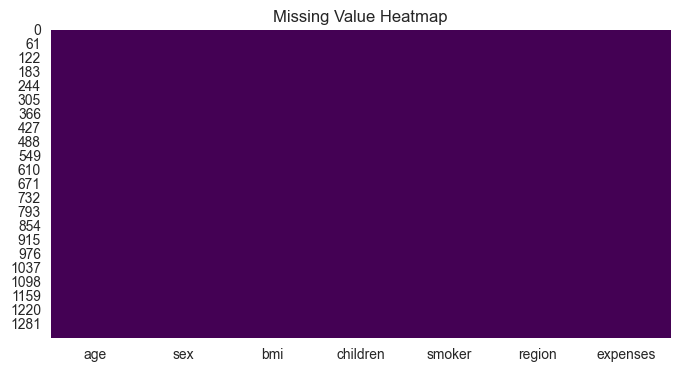

In [13]:
# Visualizing Missing Values

plt.figure(figsize=(8,4))
sns.heatmap(df.isnull(),cbar=False,cmap='viridis')
plt.title("Missing Value Heatmap")
plt.show()

The dataset consists of 1338 observations and 7 features.

There are three categorical variables:

- sex
- smoker
- region

The remaining variables are numerical.

No missing values are present in the dataset.

In [14]:
# Duplicate Records

print("Duplicate Records :", df.duplicated().sum())

Duplicate Records : 1


In [15]:
# Dropping duplicates

df = df.drop_duplicates()

In [16]:
#verify

print(df.shape)

(1337, 7)


In [17]:
# Checking data types

df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
expenses    float64
dtype: object

In [18]:
# Separate Numerical & Categorical Columns

categorical_columns = df.select_dtypes(include='object').columns
numerical_columns = df.select_dtypes(exclude='object').columns
print("Categorical Columns")
print(categorical_columns)
print()
print("Numerical Columns")
print(numerical_columns)

Categorical Columns
Index(['sex', 'smoker', 'region'], dtype='str')

Numerical Columns
Index(['age', 'bmi', 'children', 'expenses'], dtype='str')


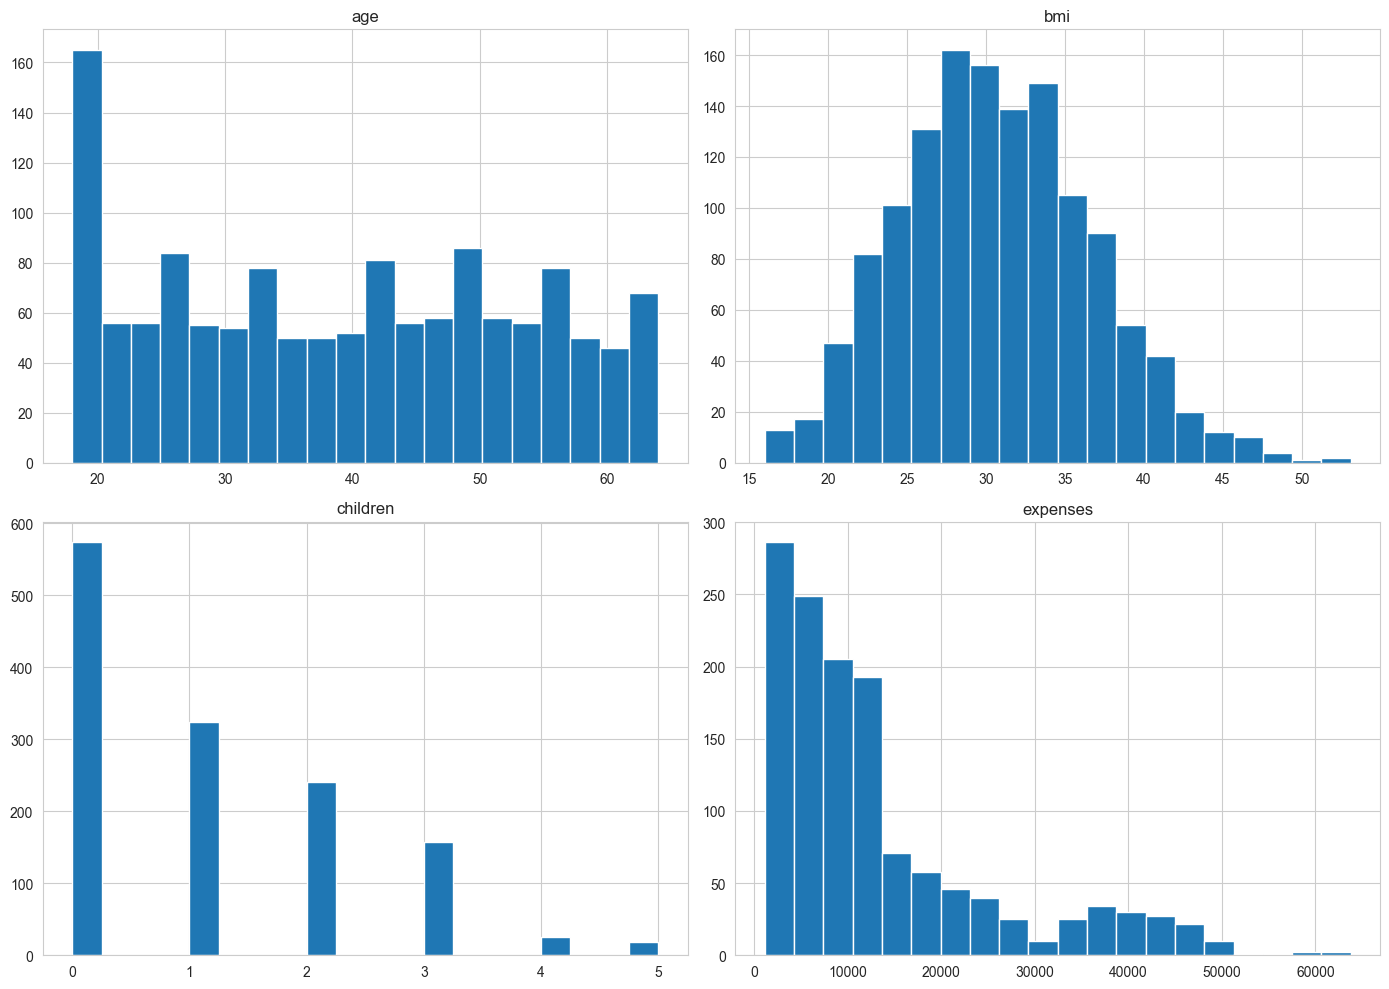

In [19]:
# Distribution of Numerical Features

df.hist(figsize=(14,10), bins=20)
plt.tight_layout()
plt.show()

### Observation :

Most numerical variables are slightly skewed.

Medical expenses are positively skewed, indicating some customers have significantly higher insurance costs.

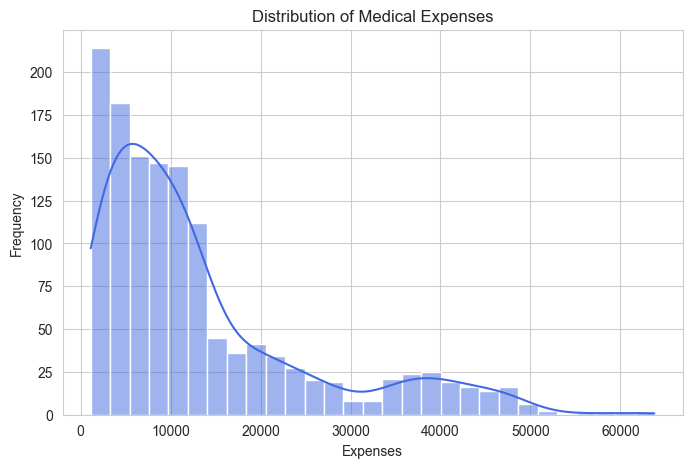

In [20]:
# Target Variable Distribution

plt.figure(figsize=(8,5))
sns.histplot(df["expenses"],kde=True,color='royalblue')
plt.title("Distribution of Medical Expenses")
plt.xlabel("Expenses")
plt.ylabel("Frequency")
plt.show()

### Observation :

The target variable (expenses) is right-skewed.

This suggests that while many individuals have moderate insurance expenses, a smaller number incur significantly higher medical costs.

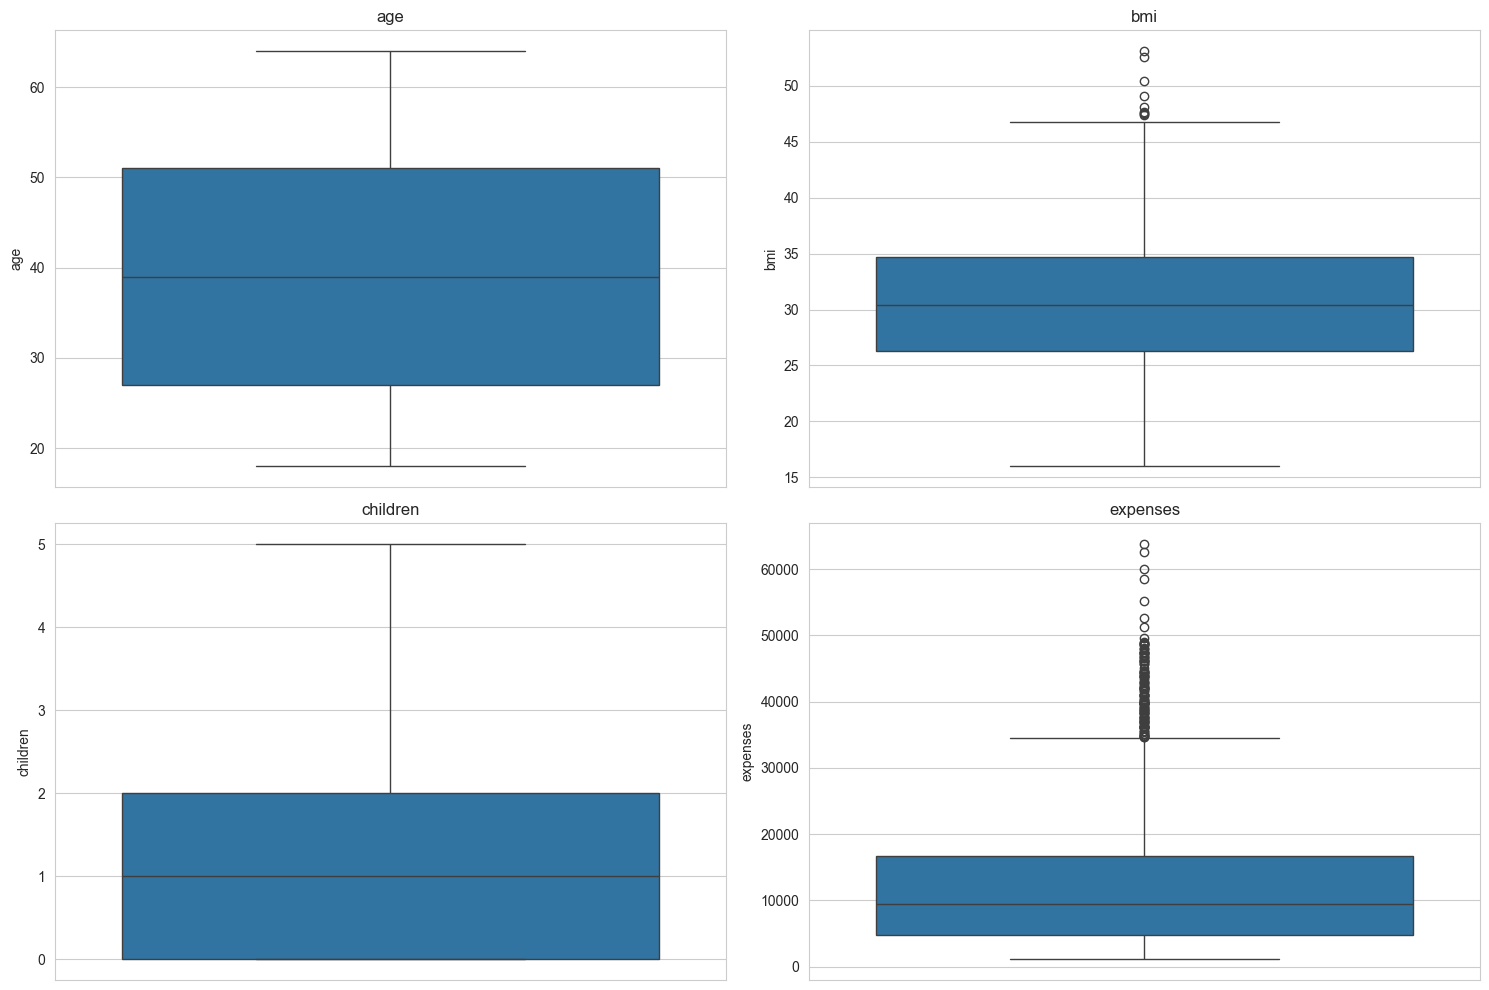

In [21]:
# Boxplots of numerical columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_columns):
    plt.subplot(2,2,i+1)
    sns.boxplot(y=df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

### Observation :

The expenses column contains several outliers, which are expected in real-world insurance datasets.

In [22]:
# Correlation Matrix

correlation = df.corr(numeric_only=True)
correlation

,age,bmi,children,expenses
age,1.000000,0.109414,0.041536,0.298308
bmi,0.109414,1.000000,0.012641,0.198637
children,0.041536,0.012641,1.000000,0.067389
expenses,0.298308,0.198637,0.067389,1.000000


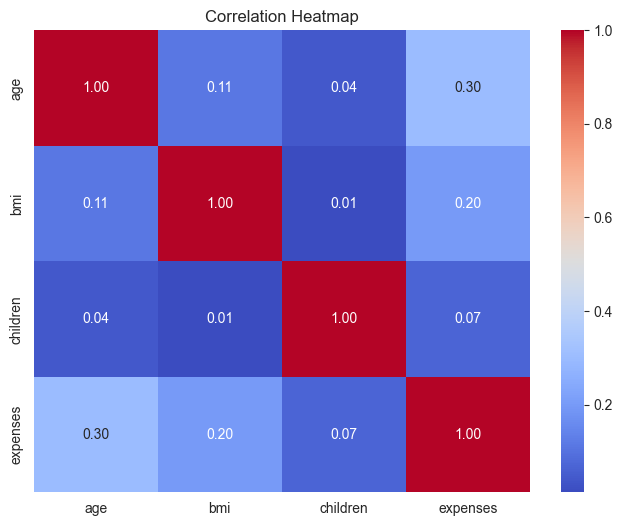

In [23]:
#Correlation Heatmap

plt.figure(figsize=(8,6))
sns.heatmap(correlation,annot=True,cmap="coolwarm",fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

### Observation:

- Age and BMI show a moderate positive relationship with expenses.
- Children have only a weak correlation with insurance expenses.

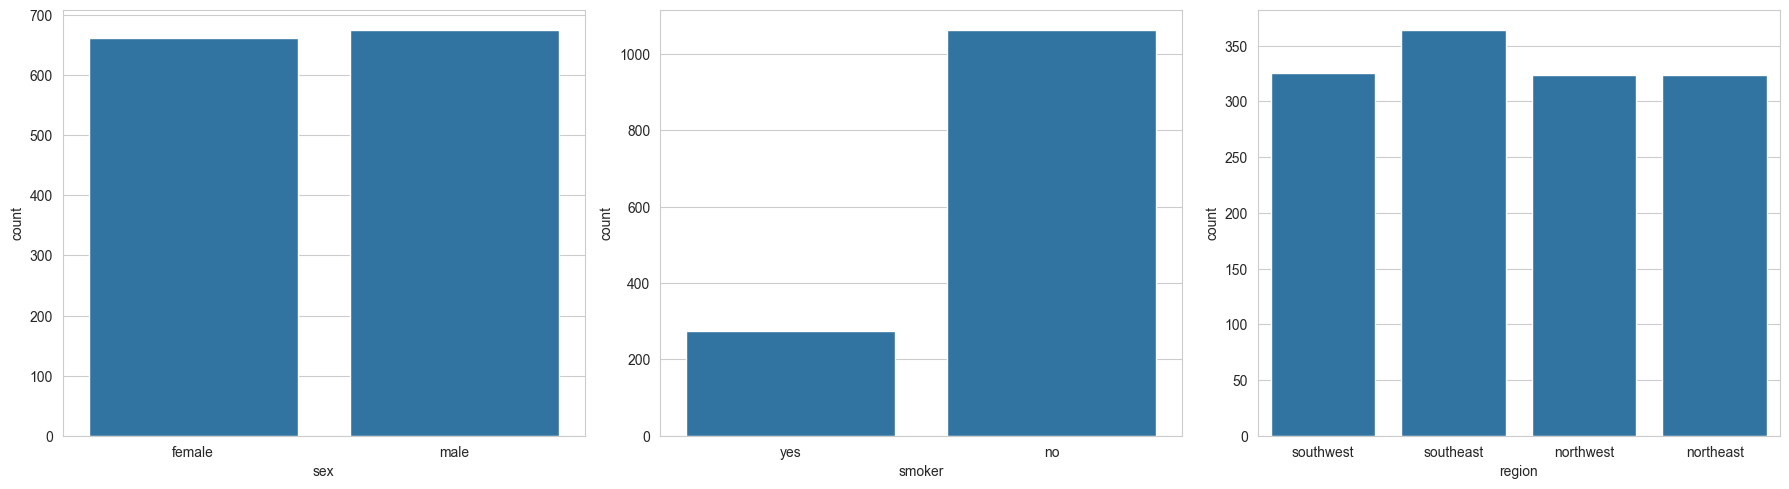

In [24]:
# Categorical Feature Analysis

fig, axes = plt.subplots(1,3, figsize=(18,5))
sns.countplot(x='sex', data=df, ax=axes[0])
sns.countplot(x='smoker', data=df, ax=axes[1])
sns.countplot(x='region', data=df, ax=axes[2])
plt.tight_layout()
plt.show()

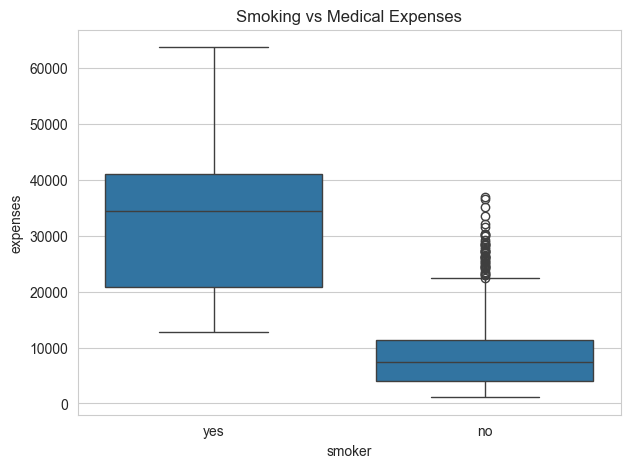

In [25]:
# Relationship with Target Variable

plt.figure(figsize=(7,5))
sns.boxplot(x='smoker', y='expenses', data=df)
plt.title("Smoking vs Medical Expenses")
plt.show()

### Observation:

Smokers incur significantly higher medical expenses compared to non-smokers.

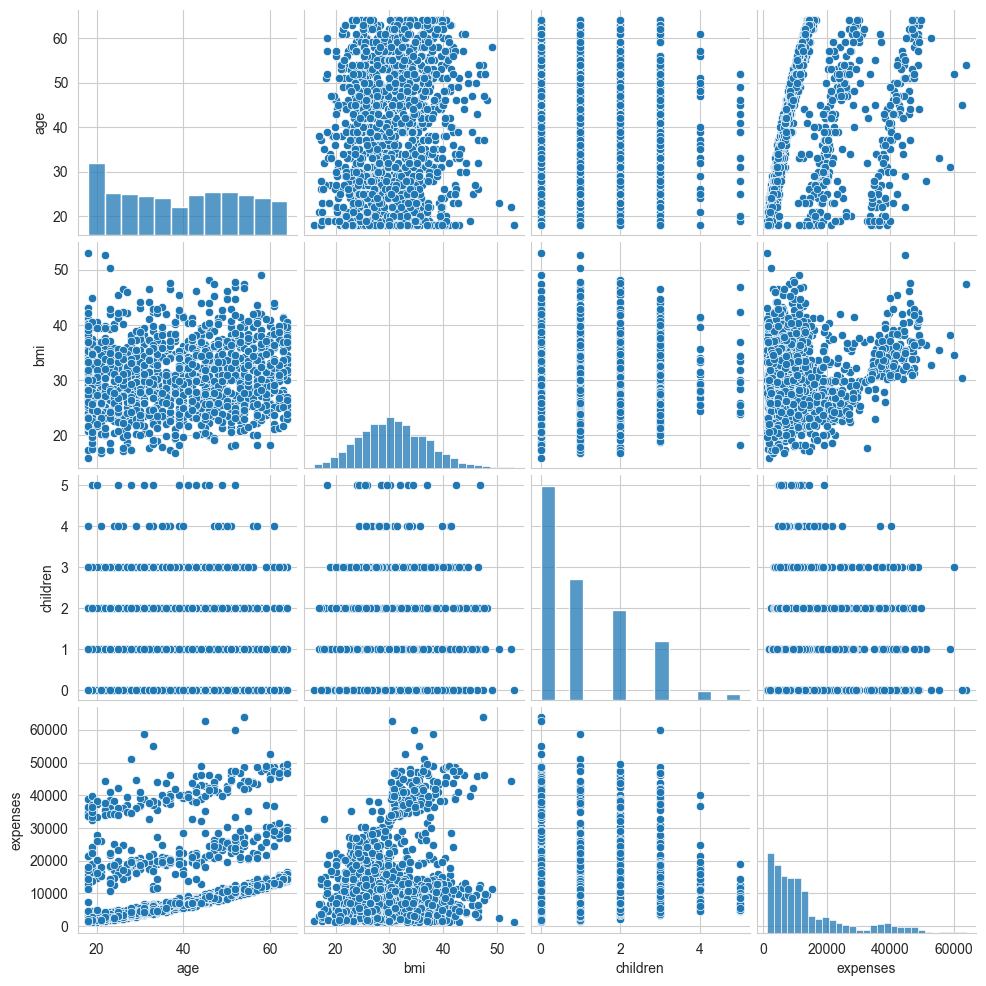

In [26]:
# Pairplot

sns.pairplot(df)
plt.show()

In [27]:
print("Exploratory Data Analysis Completed Successfully.")

Exploratory Data Analysis Completed Successfully.


## EDA Summary

### Key Findings

- The dataset contains 1338 records and 7 columns.
- No missing values are present.
- Duplicate records were checked and removed if necessary.
- Medical expenses are positively skewed.
- Smoking status shows a strong relationship with medical expenses in the dataset.
- Age and BMI show positive relationships with insurance expenses.
- Categorical variables require encoding before model training.
- Numerical variables will be standardized during preprocessing.

The dataset is now ready for Feature Engineering and Data Preprocessing.

# Feature Engineering

In this phase, the dataset is prepared for machine learning.

The following preprocessing steps are performed:

- Separate features and target variable
- Encode categorical variables using One-Hot Encoding
- Scale numerical features using StandardScaler
- Split the data into training and testing sets (80:20)

In [28]:
# Separate Features and Target

# Features (Independent Variables)

X = df.drop("expenses", axis=1)

# Target Variable (Dependent Variable)

y = df["expenses"]
print("Shape of X :", X.shape)
print("Shape of y :", y.shape)

Shape of X : (1337, 6)
Shape of y : (1337,)


In [29]:
# Display Features and Target

print("Features")
display(X.head())

print("\nTarget")
display(y.head())

Features


,age,sex,bmi,children,smoker,region
0,19,female,27.9,0,yes,southwest
1,18,male,33.8,1,no,southeast
2,28,male,33.0,3,no,southeast
3,33,male,22.7,0,no,northwest
4,32,male,28.9,0,no,northwest



Target


0    16884.92
1     1725.55
2     4449.46
3    21984.47
4     3866.86
Name: expenses, dtype: float64

In [30]:
# Separate Numerical and Categorical Columns

categorical_features = X.select_dtypes(include="object").columns.tolist()
numerical_features = X.select_dtypes(exclude="object").columns.tolist()
print("Categorical Features")
print(categorical_features)
print()
print("Numerical Features")
print(numerical_features)

Categorical Features
['sex', 'smoker', 'region']

Numerical Features
['age', 'bmi', 'children']


In [31]:
# One-Hot Encoding

X_encoded = pd.get_dummies(X,columns=categorical_features,drop_first=True)
print("Shape after Encoding :", X_encoded.shape)
X_encoded.head()

Shape after Encoding : (1337, 8)


,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.9,0,False,True,False,False,True
1,18,33.8,1,True,False,False,True,False
2,28,33.0,3,True,False,False,True,False
3,33,22.7,0,True,False,True,False,False
4,32,28.9,0,True,False,True,False,False


### Observation:

- The categorical variables were converted into numerical format using One-Hot Encoding.

- The parameter drop_first=True was used to avoid multicollinearity (Dummy Variable Trap).

# Data Preprocessing

In [32]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_encoded,y,test_size=0.20,random_state=42)
print("Training Features :", X_train.shape)
print("Testing Features :", X_test.shape)
print()
print("Training Target :", y_train.shape)
print("Testing Target :", y_test.shape)

Training Features : (1069, 8)
Testing Features : (268, 8)

Training Target : (1069,)
Testing Target : (268,)


### Observation:

The dataset was divided into:

80% Training Data

20% Testing Data

The random_state value of 42 ensures reproducibility of results.

In [33]:
from sklearn.preprocessing import StandardScaler

# Create copies of training and testing data

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
# Initialize StandardScaler
scaler = StandardScaler()

# Scale only numerical features

X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])
print("Feature Scaling Completed Successfully.")

Feature Scaling Completed Successfully.


Feature scaling standardizes numerical values so that each feature has a mean of approximately 0 and a standard deviation of 1.

The scaler was fitted only on the training data to prevent data leakage.

# Model Building

In [34]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train_scaled, y_train)
print("Linear Regression Model Trained Successfully.")

Linear Regression Model Trained Successfully.


In [35]:
# Predictions

y_pred = model.predict(X_test_scaled)
print("Prediction Completed Successfully.")

Prediction Completed Successfully.


# Model Evaluation

In [36]:
# Evaluation Metrics

from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("Model Performance")
print("-"*40)
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.4f}")

Model Performance
----------------------------------------
Mean Absolute Error (MAE): 4177.27
Root Mean Squared Error (RMSE): 5956.63
R² Score: 0.8069


### Observation:

The model performance was evaluated using:
• Mean Absolute Error (MAE)
• Root Mean Squared Error (RMSE)
• R² Score
A lower MAE and RMSE indicate better prediction accuracy, while an R² Score closer to 1 indicates better model performance.

# Model Visualization

In [37]:
# Actual vs Predicted

comparison = pd.DataFrame({"Actual": y_test.values,"Predicted": y_pred})
comparison.sample(10, random_state=42)

,Actual,Predicted
115,1986.93,5365.212612
213,7201.70,7642.658472
22,9800.89,14906.989340
132,2137.65,2360.184787
117,1135.94,3046.882715
159,8835.26,11085.929449
234,11534.87,8781.832709
137,19594.81,29873.572667
30,4347.02,6513.366315
67,37829.72,30755.526600


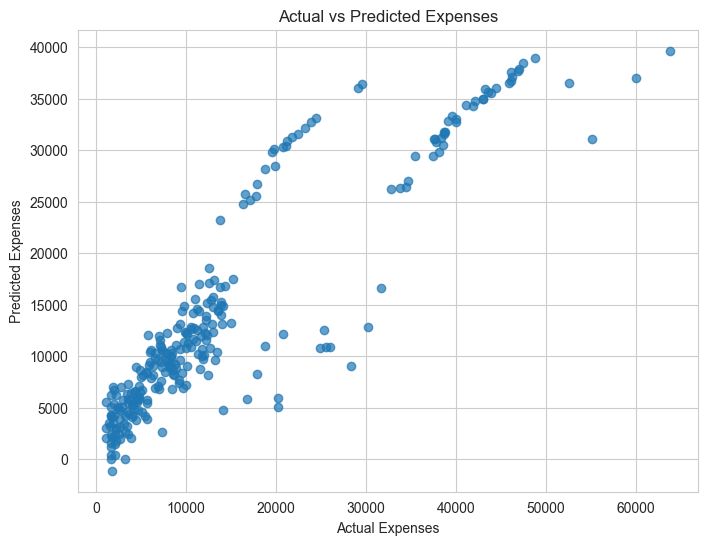

In [38]:
# Scatter Plot: Actual vs Predicted

plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred,alpha=0.7)
plt.xlabel("Actual Expenses")
plt.ylabel("Predicted Expenses")
plt.title("Actual vs Predicted Expenses")
plt.show()

The scatter plot compares the actual insurance expenses with the predicted expenses.

Points closer to the diagonal indicate better prediction performance.

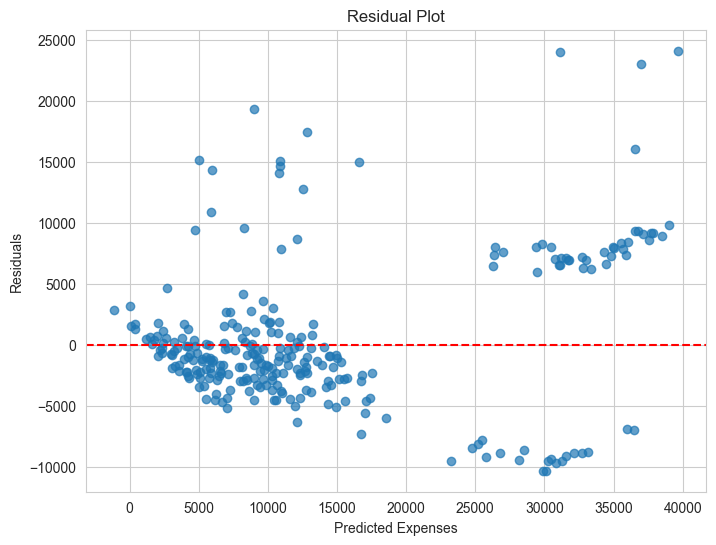

In [39]:
# Residual Plot

residuals = y_test - y_pred
plt.figure(figsize=(8,6))
plt.scatter(y_pred,residuals,alpha=0.7)
plt.axhline(y=0,color='red',linestyle='--')
plt.xlabel("Predicted Expenses")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

### Observation:

Residuals should be randomly distributed around zero.
A random pattern indicates that the regression assumptions are reasonably satisfied.

In [40]:
# Regression Coefficients

coefficients = pd.DataFrame({"Feature": X_encoded.columns,"Coefficient": model.coef_})
coefficients.sort_values(by="Coefficient",ascending=False)

,Feature,Coefficient
4,smoker_yes,23076.977936
0,age,3472.547601
1,bmi,1929.025205
2,children,636.911983
3,sex_male,-101.760064
5,region_northwest,-391.935516
7,region_southwest,-658.710746
6,region_southeast,-840.054088


### Observation:

Regression coefficients indicate the direction and magnitude of the relationship between each feature and the target variable.

Positive coefficients increase predicted expenses, while negative coefficients decrease them.

In [41]:
print("="*50)
print("Linear Regression Model Summary")
print("="*50)
print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")
print(f"Number of Features : {X_train.shape[1]}")
print()
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² Score : {r2:.4f}")
print("="*50)

Linear Regression Model Summary
Training Samples : 1069
Testing Samples  : 268
Number of Features : 8

MAE  : 4177.27
RMSE : 5956.63
R² Score : 0.8069


# Conclusion

The dataset was successfully preprocessed using One-Hot Encoding and StandardScaler.

The data was divided into training and testing sets using an 80:20 ratio.

A Linear Regression model was trained and evaluated using RMSE, MAE, and R² Score.

The diagnostic plots (Actual vs Predicted and Residual Plot) were generated to assess the model's prediction quality.

The project successfully satisfies the required stages of the machine learning pipeline:
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Data Preprocessing
- Validation Split
- Model Training
- Model Evaluation